In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile
from tqdm import tqdm
import napari
from scipy.spatial.distance import cdist

def merge_centroids(current_centroids, centroids_to_add, max_distance=25):
    """
    Merges centroids from `centroids_to_add` into `current_centroids` if they are within `max_distance`.
    """
    axes = ["px_z", "px_y", "px_x"]

    merged_centroids = current_centroids.copy()
    add_to_drop = set()
    merged_to_drop = set()
    close_distances = []

    for timepoint in set(current_centroids["timepoint"]).intersection(set(centroids_to_add["timepoint"])):

        current = current_centroids[current_centroids["timepoint"] == timepoint]
        to_add = centroids_to_add[centroids_to_add["timepoint"] == timepoint]

        x_current = current[axes].values
        x_add = to_add[axes].values

        distances = cdist(x_current, x_add)

        close_pairs = np.argwhere(distances < max_distance)

        for i, j in close_pairs:
            close_distances.append(distances[i, j])

            # keep the centroids farthest from the edge
            if to_add.iloc[j]["uv_distance_from_edge"] < current.iloc[i]["uv_distance_from_edge"]:
                add_to_drop.add(to_add.index[j])
            else:
                merged_to_drop.add(current.index[i])


    out = pd.concat([merged_centroids.drop(merged_to_drop), centroids_to_add.drop(add_to_drop)], ignore_index=True)

    return out

In [2]:
base_path = Path(r"D:\Tracking\NucleiTracking\data\interim\lightsheet\2025_03_18_trk\pieces")
centroids = pd.read_csv(base_path / "centroids_2d_from_stack.csv")

centroids["px_area"] = centroids["px_area"].abs()
centroids = centroids[centroids["px_area"] < 300]

['#d21820', '#1869ff', '#008a00']


bottom
top


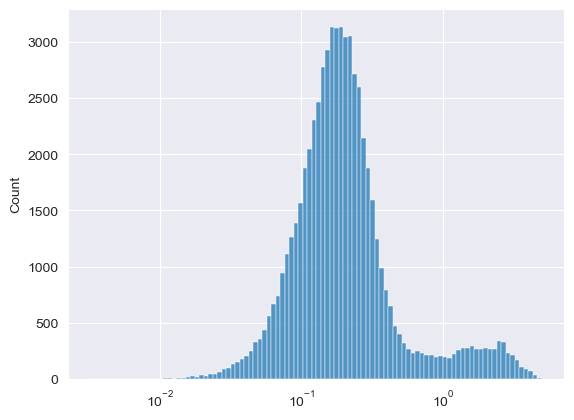

poles


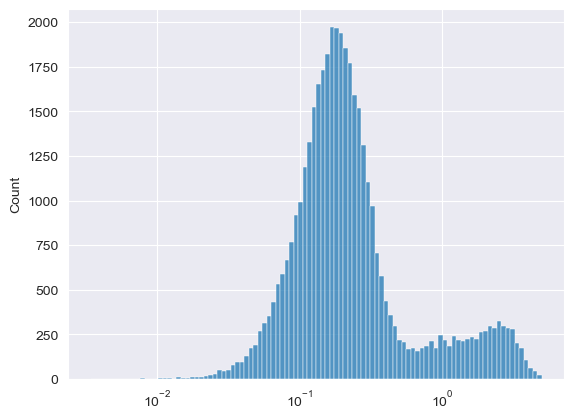

['#d21820', '#1869ff', '#008a00']


In [7]:
new_centroids = None

for mesh_name in ["bottom", "top", "poles"]:
    print(mesh_name)

    to_add = centroids[centroids["mesh_name"] == mesh_name]

    if new_centroids is None:
        new_centroids = to_add
        continue

    new_centroids = merge_centroids(new_centroids, to_add, max_distance=5)



In [8]:
new_centroids = new_centroids.dropna()
new_centroids = new_centroids.reset_index(drop=True)
new_centroids["id_prev"] = new_centroids.index.astype(np.uint32)
new_centroids.to_csv(base_path / "new_centroids.csv", index=False)

Checks

1. show that uv area maps to px area with most distortion near edges

In [ ]:
subset = centroids[centroids["mesh_name"] == "bottom"]
subset = subset[subset["timepoint"] == 200]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(subset, x="uv_u", y="uv_v", hue="uv_area", ax=axes[0], size=(subset["uv_area"] / np.pi)**(1/2))
axes[0].axis("equal")

sns.scatterplot(subset, x="uv_u", y="uv_v", hue="px_area", ax=axes[1])
axes[1].axis("equal")

plt.show()

from matplotlib.patches import Circle

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plt.xlim(0, 1024)
plt.ylim(0, 1024)

for x, y, s in zip(subset["uv_u"], subset["uv_v"], subset["px_area"]):

    r = (s / np.pi)**(1/2)

    circle = Circle((x, y), r)
    ax.add_patch(circle)

plt.show()

sns.histplot(centroids["uv_area"], bins=100, log_scale=True)
plt.show()

sns.histplot(centroids["px_area"], bins=100, log_scale=True)
plt.show()

2. distance transform edt work

In [ ]:
from scipy.ndimage import distance_transform_edt

full_locs = tifffile.imread(r"D:\Tracking\NucleiTracking\data\interim\lightsheet\2025_02_06\full_locs.tif")
dis = distance_transform_edt(1 - np.isnan(full_locs[..., 0]))

plt.imshow(dis[0], cmap="gray")
plt.show()

3. Display mesh assignment

In [ ]:
"""
new assignments:
"""

pal = ["red", "green", "blue"]

X = new_centroids[["timepoint", "px_z", "px_y", "px_x"]].values
X[:, 0] = X[:, 0] - X[:, 0].min()
X = np.round(X)
X = np.nan_to_num(X)
X = X.astype(np.int32)

mapper = {"top": pal[0], "bottom": pal[1], "poles": pal[2]}
color = [mapper[ct] for ct in new_centroids["mesh_name"]]

viewer = napari.Viewer()
viewer.theme = "light"
viewer.add_points(X, size=2* np.power(new_centroids["px_area"] / np.pi, 1/2), face_color=color, name="new_centroids")

napari.run()

In [ ]:
"""
Old assignments:
"""

subset = centroids[centroids["px_area"] > 15]
subset = centroids
X = subset[["timepoint", "px_z", "px_y", "px_x"]].values
X[:, 0] = X[:, 0] - X[:, 0].min()
X = np.round(X)
X = np.nan_to_num(X)
X = X.astype(np.int32) # create_palette(3)
print(pal)
mapper = {"top": pal[0], "bottom": pal[1], "poles": pal[2]}
color = [mapper[ct] for ct in subset["mesh_name"]]

viewer = napari.Viewer()
viewer.theme = "light"
viewer.add_points(X, size=np.power(subset["px_area"], 1/2) / .66, face_color=color, name="new_centroids")

napari.run()